# Bangladesh Telecom - Multi-Model Churn Prediction

This notebook trains and compares **four classification models** on the BD telecom churn dataset, visualises key insights, and predicts which newly-joined customers are most likely to churn.

### Models Used
| # | Model | Family |
|---|-------|--------|
| 1 | Logistic Regression | Linear |
| 2 | Random Forest | Bagging Ensemble |
| 3 | Gradient Boosting | Boosting Ensemble |
| 4 | XGBoost | Advanced Boosting |

All plots are saved to the **`Outputs/`** folder so they render on GitHub without running the notebook.

## 1 - Setup & Imports

In [1]:
# Core Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, accuracy_score,
    f1_score, precision_score, recall_score,
)

# XGBoost (optional)
try:
    from xgboost import XGBClassifier
    HAS_XGBOOST = True
    print("XGBoost loaded successfully")
except ImportError:
    HAS_XGBOOST = False
    print("XGBoost not installed. Install with:  pip install xgboost")
    print("Continuing with 3 models.")

warnings.filterwarnings("ignore")

# Plot Style
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("seaborn-whitegrid")

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
})

# Colour Palettes
STATUS_COLORS  = {"Stayed": "#2ecc71", "Churned": "#e74c3c", "Joined": "#3498db"}
MODEL_COLORS   = ["#3498db", "#2ecc71", "#f39c12", "#e74c3c"]

# Output Directory
OUTPUT_DIR = "Outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"\nPlots will be saved to: {os.path.abspath(OUTPUT_DIR)}")

XGBoost loaded successfully

Plots will be saved to: d:\Data Analytics\Projects\bd_networking_churn\Data & Resources\Python Scripts\Outputs


## 2 - Data Loading

In [2]:
# Load directly from the project CSV - no database required
DATA_PATH = os.path.join("..", "Data", "Customer_Data.csv")
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")
df.head()

Shape: 6,396 rows x 32 columns
Missing values: 1386


,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,...,Payment_Method,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,19877-DHK,Male,35,No,Dhaka,7,27,No Deal,Yes,No,...,Credit Card,492.00,4449.75,0.00,0.0,2861.32,7311.07,Stayed,Not Applicable,Not Applicable
1,58353-DHK,Female,45,Yes,Dhaka,14,13,No Deal,Yes,Yes,...,Credit Card,-30.00,4068.00,287.47,75.0,721.57,4577.10,Stayed,Not Applicable,Not Applicable
2,25063-CTG,Male,51,No,Chattogram,4,35,Deal 5,Yes,No,...,Bank Withdrawal,554.25,2106.38,0.00,0.0,1009.50,3115.88,Churned,Competitor,Competitor had better devices
3,59787-KHU,Male,79,No,Khulna,3,21,Deal 4,Yes,No,...,Bank Withdrawal,735.00,9283.88,0.00,0.0,2712.45,11996.33,Churned,Dissatisfaction,Product dissatisfaction
4,28544-KHU,Female,80,No,Khulna,3,8,No Deal,Yes,No,...,Credit Card,629.25,2005.50,0.00,0.0,166.05,2171.55,Churned,Dissatisfaction,Network reliability


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6396 entries, 0 to 6395
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Customer_ID                  6396 non-null   str    
 1   Gender                       6396 non-null   str    
 2   Age                          6396 non-null   int64  
 3   Married                      6396 non-null   str    
 4   State                        6396 non-null   str    
 5   Number_of_Referrals          6396 non-null   int64  
 6   Tenure_in_Months             6396 non-null   int64  
 7   Value_Deal                   6396 non-null   str    
 8   Phone_Service                6396 non-null   str    
 9   Multiple_Lines               6396 non-null   str    
 10  Internet_Service             6396 non-null   str    
 11  Internet_Type                5010 non-null   str    
 12  Online_Security              6396 non-null   str    
 13  Online_Backup                

In [4]:
df.describe()

,Age,Number_of_Referrals,Tenure_in_Months,Monthly_Charge,Total_Charges,Total_Refunds,Total_Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue
count,6396.000000,6396.000000,6396.000000,6396.000000,6396.000000,6396.000000,6396.000000,6396.000000,6396.000000
mean,47.085522,7.426673,17.333177,477.188011,17087.166306,14.486750,50.375235,5614.334203,22737.388876
std,16.705779,4.620460,10.577027,233.894414,16996.152009,58.963192,185.290951,6356.347856,21483.521676
min,18.000000,0.000000,1.000000,-75.000000,141.000000,0.000000,0.000000,0.000000,160.200000
25%,33.000000,3.000000,8.000000,228.750000,2969.812500,0.000000,0.000000,530.720000,4523.512500
50%,46.000000,7.000000,16.000000,525.380000,10466.440000,0.000000,0.000000,3056.060000,15814.765000
75%,60.000000,11.000000,27.000000,672.750000,28337.720000,0.000000,0.000000,8867.640000,35896.515000
max,85.000000,15.000000,36.000000,890.620000,65136.000000,373.430000,1125.000000,26735.400000,89845.050000


## 3 - Exploratory Data Analysis

### 3.1  Target Variable - Customer Status

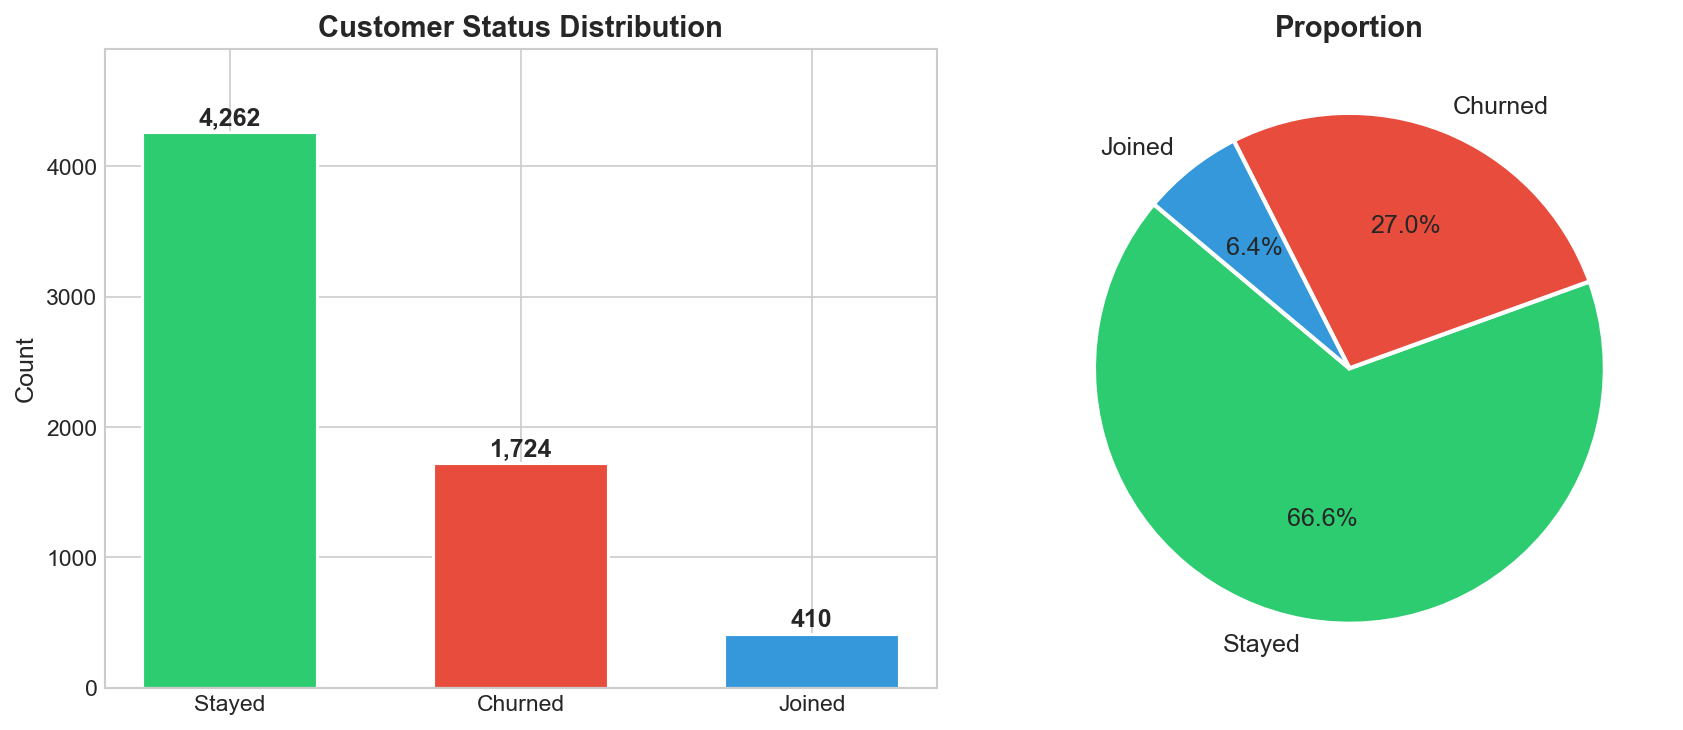

Saved: 01_target_distribution.png


In [5]:
status_counts = df["Customer_Status"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(
    status_counts.index, status_counts.values,
    color=[STATUS_COLORS[s] for s in status_counts.index],
    edgecolor="white", linewidth=1.5, width=0.6,
)
for bar, val in zip(bars, status_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 60,
                 f"{val:,}", ha="center", fontweight="bold", fontsize=12)
axes[0].set_title("Customer Status Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, status_counts.max() * 1.15)

# Pie chart
axes[1].pie(
    status_counts.values, labels=status_counts.index,
    colors=[STATUS_COLORS[s] for s in status_counts.index],
    autopct="%1.1f%%", startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 12},
)
axes[1].set_title("Proportion", fontweight="bold")

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "01_target_distribution.png"), bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: 01_target_distribution.png")

### 3.2  Churn Rate by Contract Type

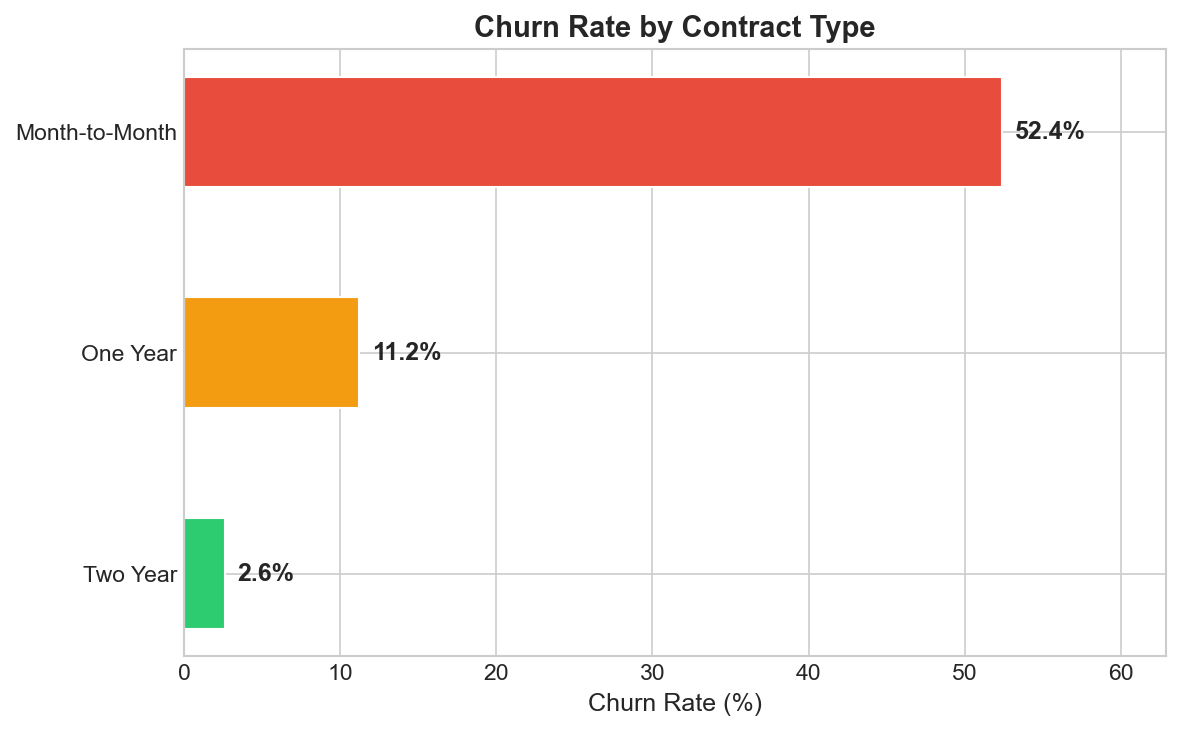

Saved: 02_churn_by_contract.png


In [6]:
contract_churn = df[df["Customer_Status"].isin(["Stayed", "Churned"])].copy()
ct = pd.crosstab(contract_churn["Contract"], contract_churn["Customer_Status"])
ct["Churn Rate %"] = (ct["Churned"] / (ct["Churned"] + ct["Stayed"]) * 100).round(1)
ct = ct.sort_values("Churn Rate %", ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(ct.index, ct["Churn Rate %"], color=["#e74c3c", "#f39c12", "#2ecc71"], edgecolor="white", height=0.5)
for bar, val in zip(bars, ct["Churn Rate %"]):
    ax.text(bar.get_width() + 0.8, bar.get_y() + bar.get_height()/2,
            f"{val}%", va="center", fontweight="bold", fontsize=12)
ax.set_xlabel("Churn Rate (%)")
ax.set_title("Churn Rate by Contract Type", fontweight="bold")
ax.set_xlim(0, ct["Churn Rate %"].max() * 1.2)
ax.invert_yaxis()

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "02_churn_by_contract.png"), bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: 02_churn_by_contract.png")

### 3.3  Churn Rate by Tenure Group

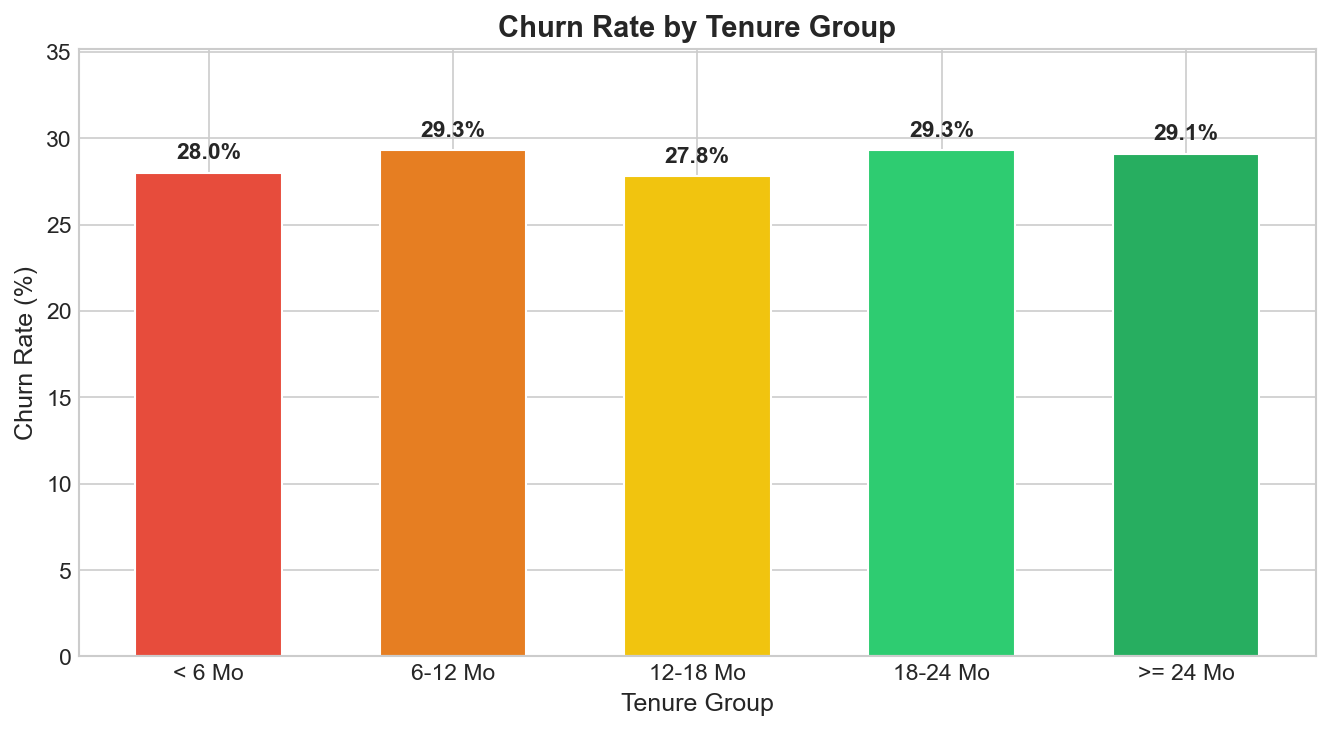

Saved: 03_churn_by_tenure.png


In [7]:
def tenure_group(months):
    if months < 6:   return "< 6 Mo"
    if months < 12:  return "6-12 Mo"
    if months < 18:  return "12-18 Mo"
    if months < 24:  return "18-24 Mo"
    return ">= 24 Mo"

tenure_order = ["< 6 Mo", "6-12 Mo", "12-18 Mo", "18-24 Mo", ">= 24 Mo"]

temp = df[df["Customer_Status"].isin(["Stayed", "Churned"])].copy()
temp["Tenure_Group"] = temp["Tenure_in_Months"].apply(tenure_group)
temp["Tenure_Group"] = pd.Categorical(temp["Tenure_Group"], categories=tenure_order, ordered=True)

ct = pd.crosstab(temp["Tenure_Group"], temp["Customer_Status"])
ct["Churn Rate %"] = (ct["Churned"] / (ct["Churned"] + ct["Stayed"]) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ["#e74c3c", "#e67e22", "#f1c40f", "#2ecc71", "#27ae60"]
bars = ax.bar(ct.index.astype(str), ct["Churn Rate %"], color=colors, edgecolor="white", width=0.6)
for bar, val in zip(bars, ct["Churn Rate %"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f"{val}%", ha="center", fontweight="bold", fontsize=11)
ax.set_ylabel("Churn Rate (%)")
ax.set_xlabel("Tenure Group")
ax.set_title("Churn Rate by Tenure Group", fontweight="bold")
ax.set_ylim(0, ct["Churn Rate %"].max() * 1.2)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "03_churn_by_tenure.png"), bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: 03_churn_by_tenure.png")

### 3.4  Monthly Charge Distribution by Status

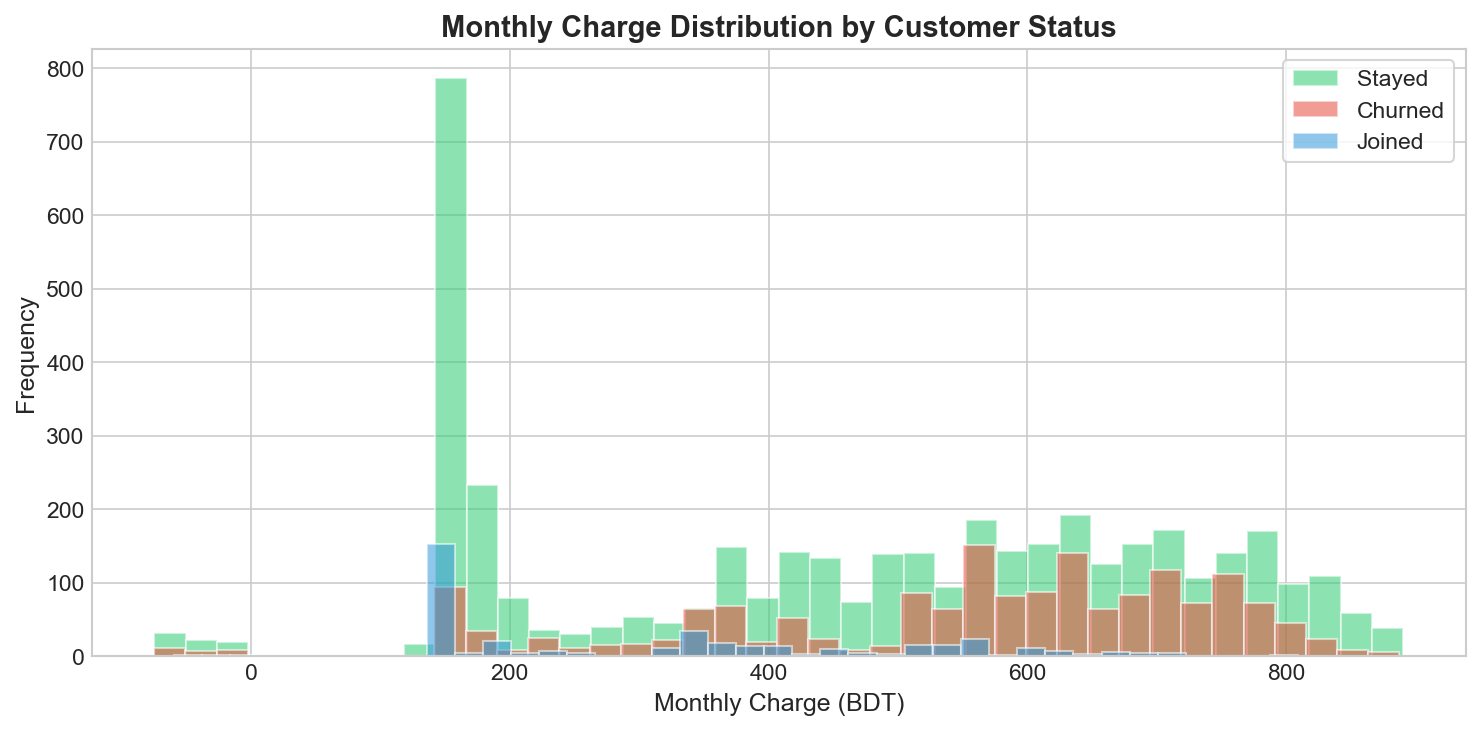

Saved: 04_monthly_charge_distribution.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
for status, color in STATUS_COLORS.items():
    subset = df[df["Customer_Status"] == status]["Monthly_Charge"]
    if len(subset) > 0:
        ax.hist(subset, bins=40, alpha=0.55, label=status, color=color, edgecolor="white")

ax.set_xlabel("Monthly Charge (BDT)")
ax.set_ylabel("Frequency")
ax.set_title("Monthly Charge Distribution by Customer Status", fontweight="bold")
ax.legend(fontsize=11, frameon=True)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "04_monthly_charge_distribution.png"), bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: 04_monthly_charge_distribution.png")

### 3.5  Correlation Heatmap (Numeric Features)

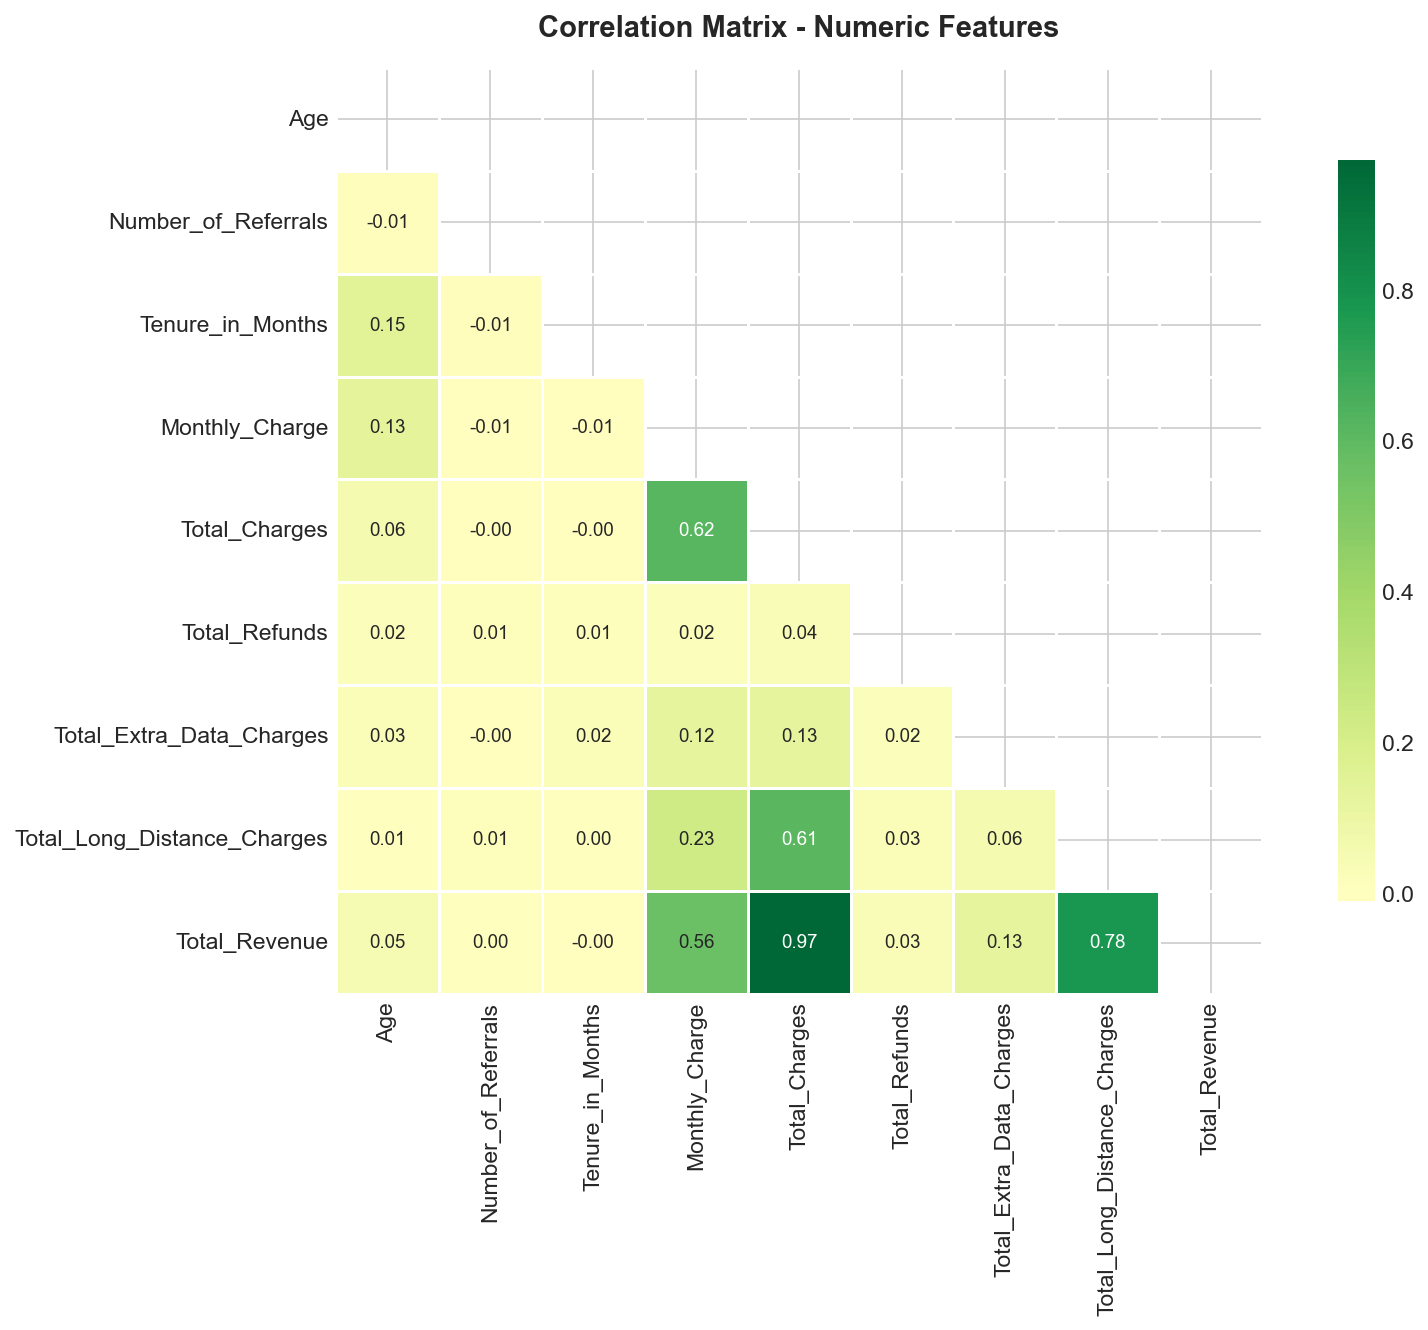

Saved: 05_correlation_heatmap.png


In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn",
    center=0, square=True, linewidths=0.5, ax=ax,
    cbar_kws={"shrink": 0.8},
    annot_kws={"size": 9},
)
ax.set_title("Correlation Matrix - Numeric Features", fontweight="bold", pad=15)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "05_correlation_heatmap.png"), bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: 05_correlation_heatmap.png")

## 4 - Data Preprocessing

Split the data into:
- **Training set** - customers who `Stayed` or `Churned` (binary classification)
- **Prediction set** - customers who `Joined` (new customers to predict on later)

In [10]:
# Separate training data (Stayed + Churned) from joiners
train_df = df[df["Customer_Status"].isin(["Stayed", "Churned"])].copy()
join_df  = df[df["Customer_Status"] == "Joined"].copy()

print(f"Training records : {len(train_df):,}  (Stayed + Churned)")
print(f"Joiner records   : {len(join_df):,}   (for prediction)")

# Keep a clean copy of joiners for later
join_df_original = join_df.copy()

# Drop columns not useful for modelling
drop_cols = ["Customer_ID", "Churn_Category", "Churn_Reason"]
train_df = train_df.drop(columns=drop_cols)
join_df  = join_df.drop(columns=drop_cols + ["Customer_Status"])

# Identify categorical columns
cat_cols = train_df.select_dtypes(include=["object"]).columns.tolist()
cat_cols.remove("Customer_Status")  # target - encode separately
print(f"\nCategorical columns to encode ({len(cat_cols)}):\n{cat_cols}")

Training records : 5,986  (Stayed + Churned)
Joiner records   : 410   (for prediction)

Categorical columns to encode (19):
['Gender', 'Married', 'State', 'Value_Deal', 'Phone_Service', 'Multiple_Lines', 'Internet_Service', 'Internet_Type', 'Online_Security', 'Online_Backup', 'Device_Protection_Plan', 'Premium_Support', 'Streaming_TV', 'Streaming_Movies', 'Streaming_Music', 'Unlimited_Data', 'Contract', 'Paperless_Billing', 'Payment_Method']


In [11]:
# Label-encode categorical features
label_encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    train_df[col] = le.fit_transform(train_df[col])
    label_encoders[col] = le

# Encode target variable
train_df["Customer_Status"] = train_df["Customer_Status"].map({"Stayed": 0, "Churned": 1})

# Features & Target
X = train_df.drop(columns=["Customer_Status"])
y = train_df["Customer_Status"]

print(f"Feature matrix : {X.shape}")
print(f"Target balance : Stayed={sum(y==0):,}  |  Churned={sum(y==1):,}")

# Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y,
)
print(f"\nTrain set : {X_train.shape[0]:,}")
print(f"Test set  : {X_test.shape[0]:,}")

Feature matrix : (5986, 28)
Target balance : Stayed=4,262  |  Churned=1,724

Train set : 4,788
Test set  : 1,198


## 5 - Model Training & Evaluation

Training four classifiers and comparing their performance:

| Model | Why |
|-------|-----|
| **Logistic Regression** | Simple linear baseline - fast, interpretable |
| **Random Forest** | Bagging ensemble - handles non-linearity, robust to outliers |
| **Gradient Boosting** | Boosting ensemble - sequential error correction |
| **XGBoost** | Advanced boosting - regularised, highly performant on tabular data |

In [12]:
# Define Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
}

if HAS_XGBOOST:
    models["XGBoost"] = XGBClassifier(
        n_estimators=100, random_state=42,
        eval_metric="logloss", verbosity=0,
    )

# Train all models
results = {}

for name, model in models.items():
    print(f"Training {name}...", end=" ")
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "model": model,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall":    recall_score(y_test, y_pred),
        "f1":        f1_score(y_test, y_pred),
        "auc":       auc(*roc_curve(y_test, y_proba)[:2]),
    }
    print(f"Done.  Accuracy={results[name]['accuracy']:.4f}  |  F1={results[name]['f1']:.4f}")

print("\nAll models trained successfully.")

Training Logistic Regression... Done.  Accuracy=0.8130  |  F1=0.6304
Training Random Forest... Done.  Accuracy=0.8531  |  F1=0.7086
Training Gradient Boosting... Done.  Accuracy=0.8564  |  F1=0.7235
Training XGBoost... Done.  Accuracy=0.8322  |  F1=0.6874

All models trained successfully.


### 5.1  Classification Reports

In [13]:
for name, res in results.items():
    print(f"\n{'='*60}")
    print(f" {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, res["y_pred"], target_names=["Stayed", "Churned"]))


 Logistic Regression
              precision    recall  f1-score   support

      Stayed       0.84      0.92      0.87       853
     Churned       0.73      0.55      0.63       345

    accuracy                           0.81      1198
   macro avg       0.78      0.74      0.75      1198
weighted avg       0.81      0.81      0.80      1198


 Random Forest
              precision    recall  f1-score   support

      Stayed       0.86      0.95      0.90       853
     Churned       0.83      0.62      0.71       345

    accuracy                           0.85      1198
   macro avg       0.84      0.78      0.81      1198
weighted avg       0.85      0.85      0.85      1198


 Gradient Boosting
              precision    recall  f1-score   support

      Stayed       0.87      0.94      0.90       853
     Churned       0.81      0.65      0.72       345

    accuracy                           0.86      1198
   macro avg       0.84      0.80      0.81      1198
weighted avg    

### 5.2  Confusion Matrices

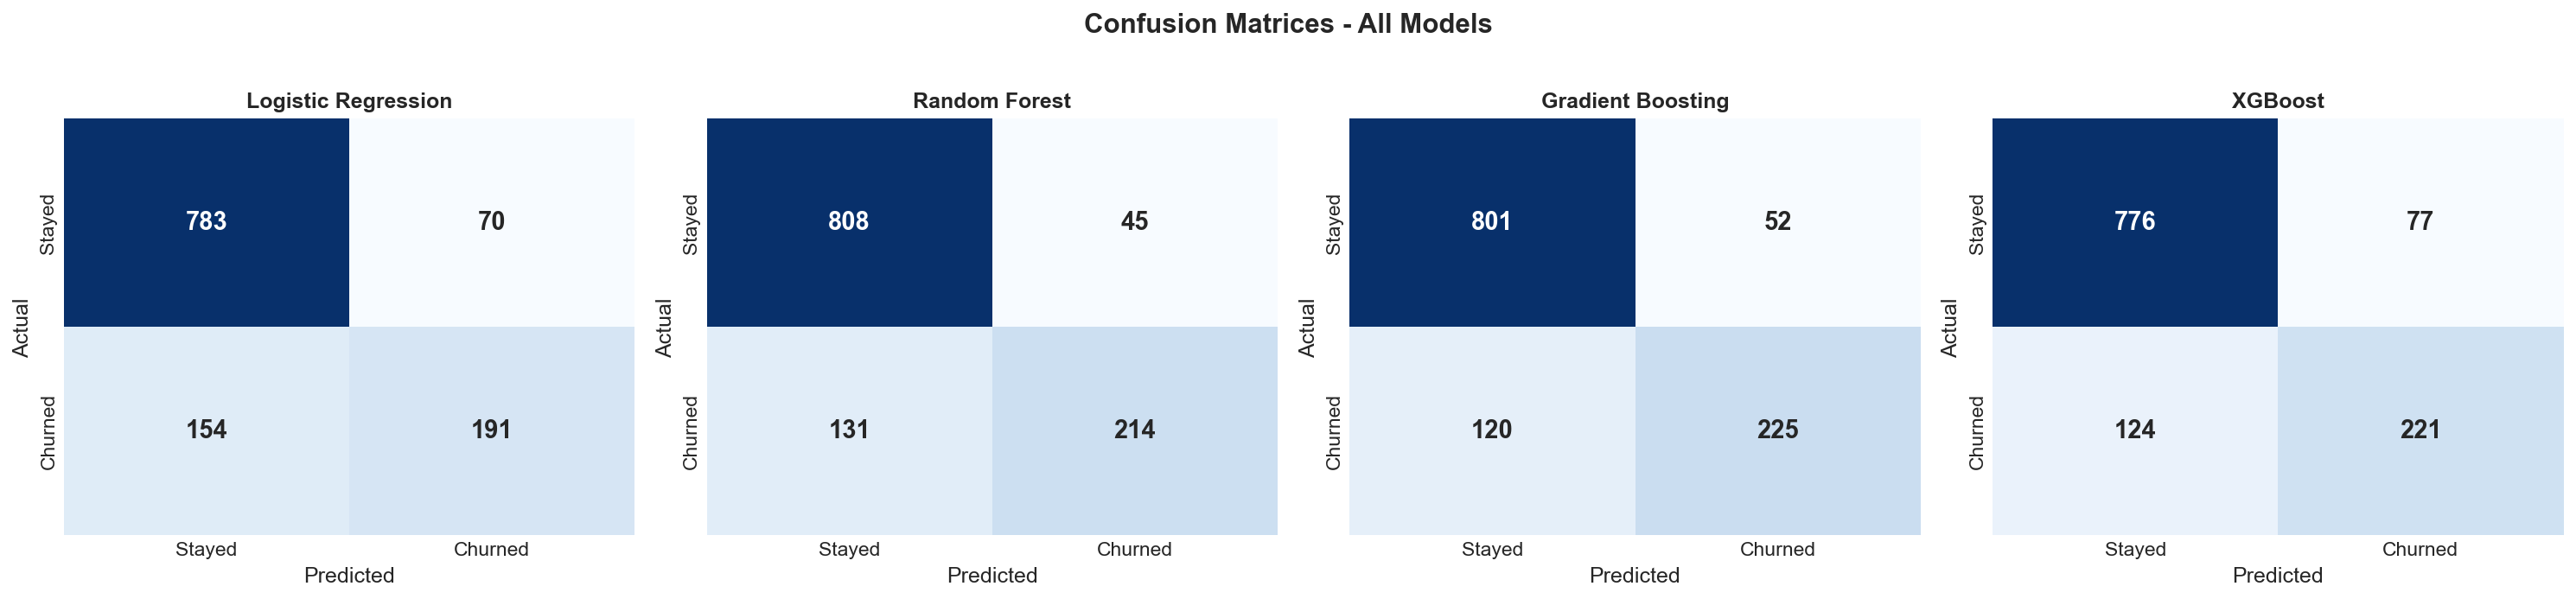

Saved: 06_confusion_matrices.png


In [14]:
n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4.5))
if n_models == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=["Stayed", "Churned"],
        yticklabels=["Stayed", "Churned"],
        ax=ax, cbar=False,
        annot_kws={"size": 14, "fontweight": "bold"},
    )
    ax.set_title(name, fontweight="bold", fontsize=12)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.suptitle("Confusion Matrices - All Models", fontweight="bold", fontsize=15, y=1.02)
plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "06_confusion_matrices.png"), bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: 06_confusion_matrices.png")

### 5.3  ROC Curves

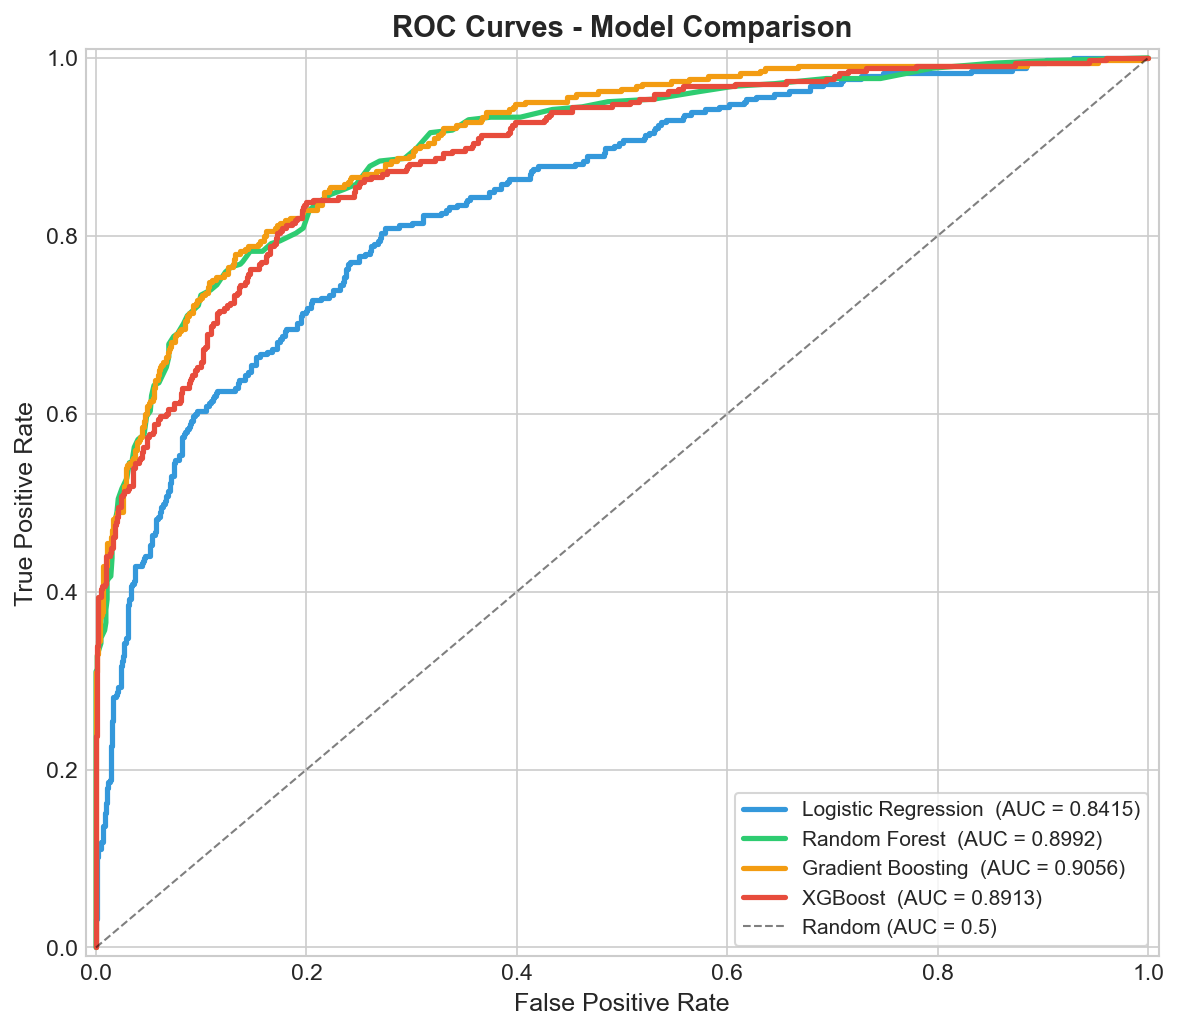

Saved: 07_roc_curves.png


In [15]:
fig, ax = plt.subplots(figsize=(8, 7))

for i, (name, res) in enumerate(results.items()):
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=MODEL_COLORS[i], linewidth=2.5,
            label=f"{name}  (AUC = {roc_auc:.4f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.5, label="Random (AUC = 0.5)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves - Model Comparison", fontweight="bold")
ax.legend(loc="lower right", fontsize=10, frameon=True)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "07_roc_curves.png"), bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: 07_roc_curves.png")

### 5.4  Model Comparison

In [16]:
# Build comparison dataframe
metrics_df = pd.DataFrame({
    name: {
        "Accuracy":  res["accuracy"],
        "Precision": res["precision"],
        "Recall":    res["recall"],
        "F1 Score":  res["f1"],
        "AUC":       res["auc"],
    }
    for name, res in results.items()
}).T

print(metrics_df.round(4).to_string())

                     Accuracy  Precision  Recall  F1 Score     AUC
Logistic Regression    0.8130     0.7318  0.5536    0.6304  0.8415
Random Forest          0.8531     0.8263  0.6203    0.7086  0.8992
Gradient Boosting      0.8564     0.8123  0.6522    0.7235  0.9056
XGBoost                0.8322     0.7416  0.6406    0.6874  0.8913


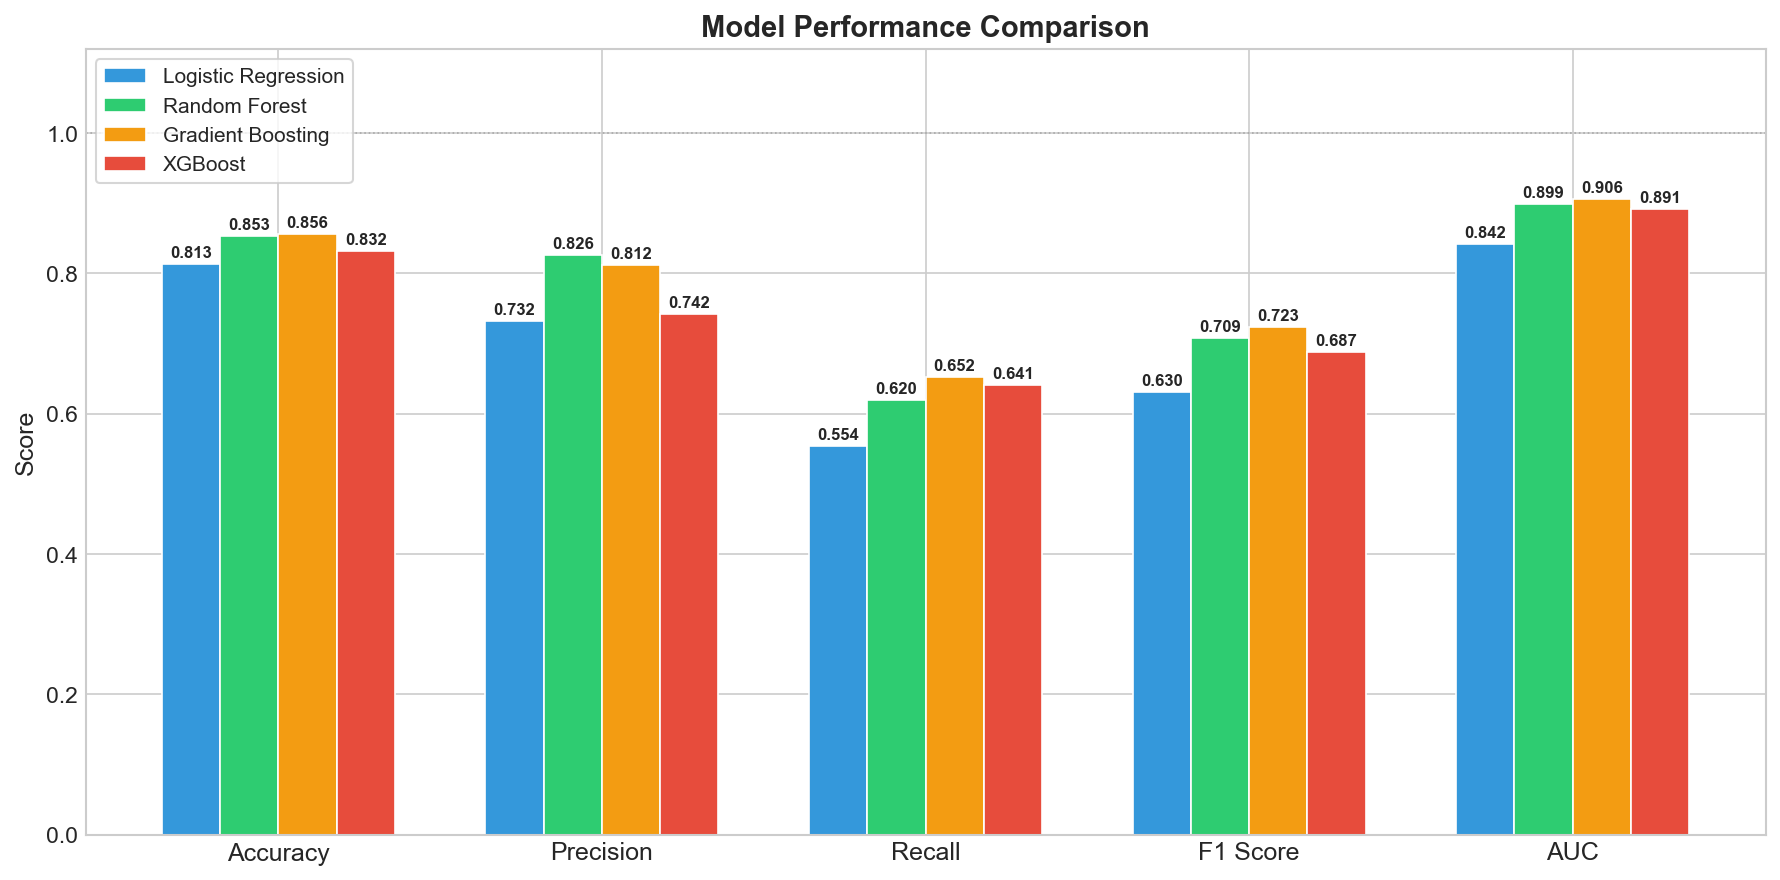

Saved: 08_model_comparison.png


In [17]:
# Grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metrics_df.columns))
width = 0.18
n = len(metrics_df)

for i, (model_name, row) in enumerate(metrics_df.iterrows()):
    offset = (i - n/2 + 0.5) * width
    bars = ax.bar(x + offset, row.values, width,
                  label=model_name, color=MODEL_COLORS[i],
                  edgecolor="white", linewidth=0.8)
    for bar, val in zip(bars, row.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.3f}", ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(metrics_df.columns, fontsize=12)
ax.set_ylabel("Score")
ax.set_ylim(0, 1.12)
ax.set_title("Model Performance Comparison", fontweight="bold", fontsize=14)
ax.legend(loc="upper left", fontsize=10, frameon=True)
ax.axhline(y=1.0, color="grey", linestyle=":", linewidth=0.8, alpha=0.5)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "08_model_comparison.png"), bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: 08_model_comparison.png")

## 6 - Feature Importance (Best Model)

Pick the model with the highest **F1 Score** and visualise its feature importances.

Best model: Gradient Boosting  (F1 = 0.7235)


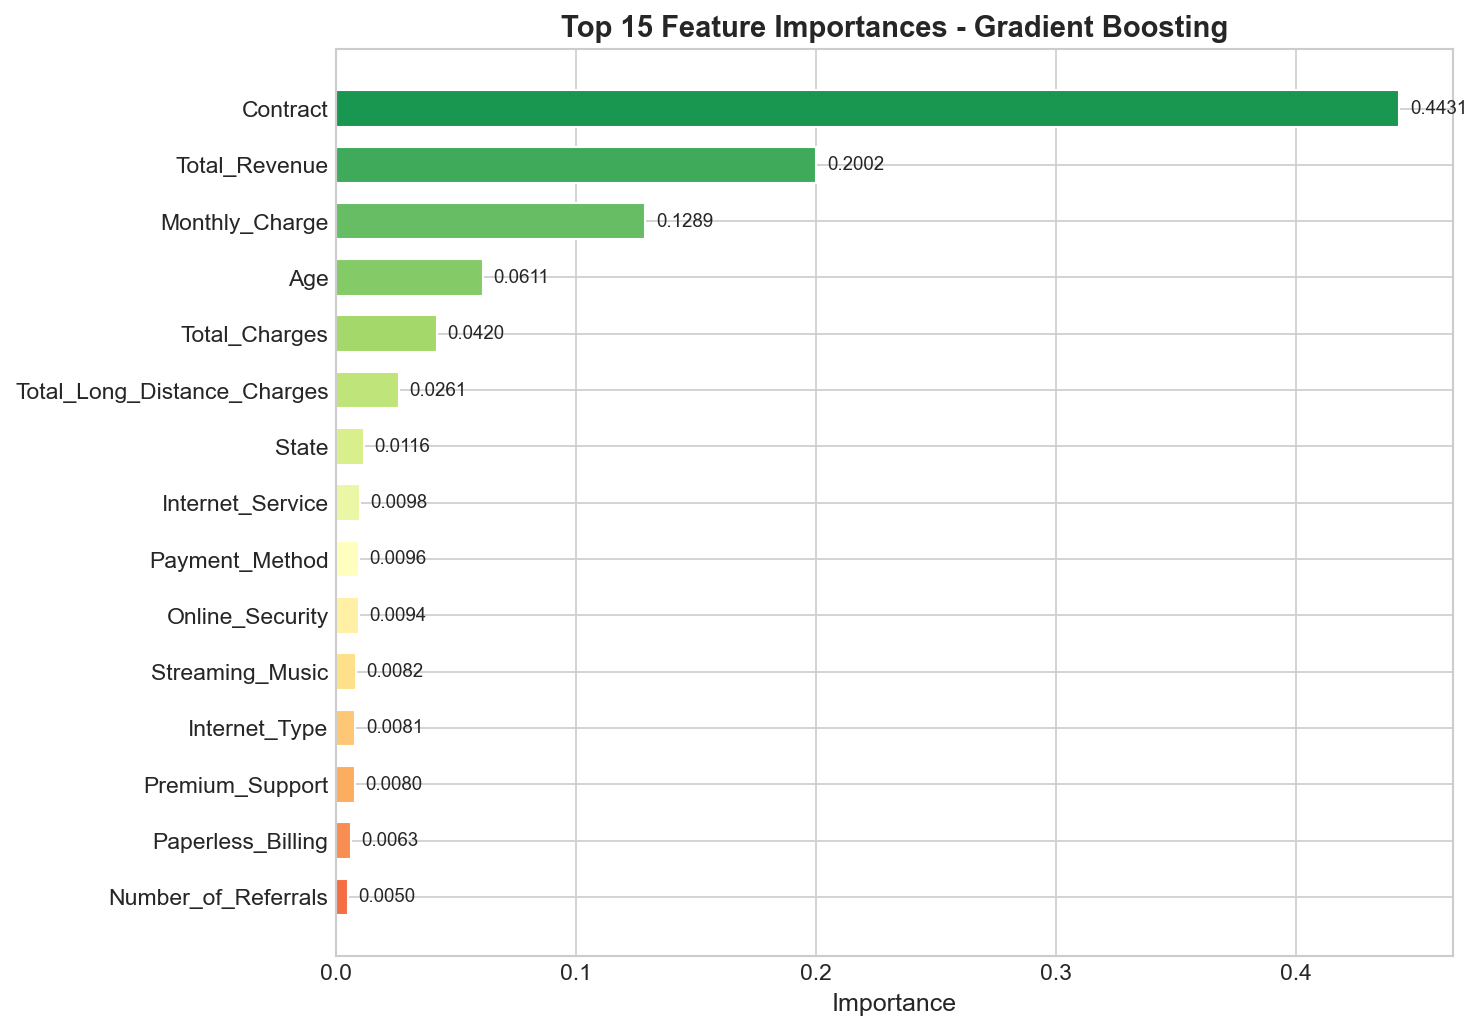

Saved: 09_feature_importance.png


In [18]:
# Find the best model by F1
best_name = max(results, key=lambda k: results[k]["f1"])
best_model = results[best_name]["model"]
print(f"Best model: {best_name}  (F1 = {results[best_name]['f1']:.4f})")

# Extract feature importances
if hasattr(best_model, "feature_importances_"):
    importances = best_model.feature_importances_
elif hasattr(best_model, "coef_"):
    importances = np.abs(best_model.coef_[0])
else:
    importances = None

if importances is not None:
    feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=True)
    top_n = feat_imp.tail(15)

    fig, ax = plt.subplots(figsize=(10, 7))
    colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(top_n)))
    ax.barh(top_n.index, top_n.values, color=colors, edgecolor="white", height=0.65)
    for i, (val, name) in enumerate(zip(top_n.values, top_n.index)):
        ax.text(val + top_n.max() * 0.01, i, f"{val:.4f}", va="center", fontsize=9)
    ax.set_xlabel("Importance")
    ax.set_title(f"Top 15 Feature Importances - {best_name}", fontweight="bold")

    plt.tight_layout()
    fig.savefig(os.path.join(OUTPUT_DIR, "09_feature_importance.png"), bbox_inches="tight", facecolor="white")
    plt.show()
    print("Saved: 09_feature_importance.png")
else:
    print("Selected model does not expose feature importances.")

## 7 - Predict Churn on Newly Joined Customers

Apply the best-performing model to the **411 recently joined** customers to identify those at risk of churning.

In [19]:
# Encode joiner data using the SAME label encoders
join_encoded = join_df.copy()
for col in cat_cols:
    if col in join_encoded.columns:
        join_encoded[col] = label_encoders[col].transform(join_encoded[col])

# Predict
predictions = best_model.predict(join_encoded)
pred_proba  = best_model.predict_proba(join_encoded)[:, 1]

join_df_original["Predicted_Status"] = np.where(predictions == 1, "Likely to Churn", "Likely to Stay")
join_df_original["Churn_Probability"] = (pred_proba * 100).round(2)

predicted_churners = join_df_original[join_df_original["Predicted_Status"] == "Likely to Churn"]

print(f"Total new joiners   : {len(join_df_original):,}")
print(f"Predicted to CHURN  : {len(predicted_churners):,}")
print(f"Predicted to STAY   : {len(join_df_original) - len(predicted_churners):,}")
print(f"Predicted churn rate: {len(predicted_churners)/len(join_df_original)*100:.1f}%")

Total new joiners   : 410
Predicted to CHURN  : 376
Predicted to STAY   : 34
Predicted churn rate: 91.7%


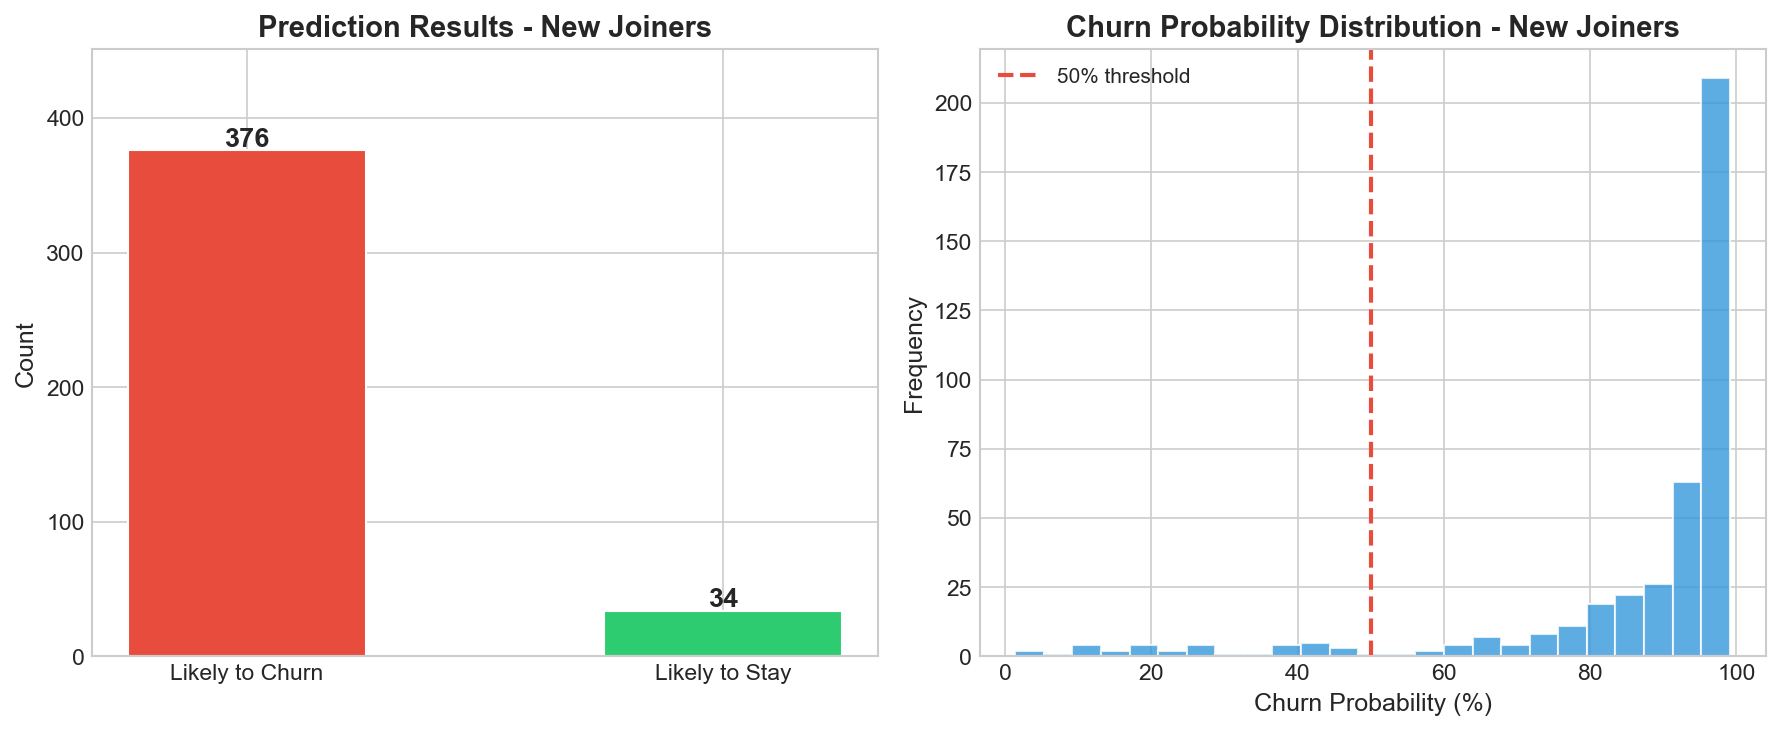

Saved: 10_prediction_results.png


In [20]:
# Visualise prediction results
pred_counts = join_df_original["Predicted_Status"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bar_colors = ["#e74c3c" if x == "Likely to Churn" else "#2ecc71" for x in pred_counts.index]
bars = axes[0].bar(pred_counts.index, pred_counts.values, color=bar_colors,
                   edgecolor="white", width=0.5)
for bar, val in zip(bars, pred_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
                 f"{val}", ha="center", fontweight="bold", fontsize=13)
axes[0].set_title("Prediction Results - New Joiners", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, pred_counts.max() * 1.2)

# Probability histogram
axes[1].hist(join_df_original["Churn_Probability"], bins=25, color="#3498db",
             edgecolor="white", alpha=0.8)
axes[1].axvline(x=50, color="#e74c3c", linestyle="--", linewidth=2, label="50% threshold")
axes[1].set_xlabel("Churn Probability (%)")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Churn Probability Distribution - New Joiners", fontweight="bold")
axes[1].legend(fontsize=10)

plt.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "10_prediction_results.png"), bbox_inches="tight", facecolor="white")
plt.show()
print("Saved: 10_prediction_results.png")

In [21]:
# Save predicted churners to CSV
output_csv = os.path.join(OUTPUT_DIR, "Predicted_Churners.csv")
predicted_churners.to_csv(output_csv, index=False)
print(f"Predicted churners saved to: {output_csv}")
print(f"Rows: {len(predicted_churners):,}")

# Preview
predicted_churners[["Customer_ID", "Gender", "Age", "State", "Contract",
                    "Monthly_Charge", "Tenure_in_Months", "Churn_Probability"]].head(10)

Predicted churners saved to: Outputs\Predicted_Churners.csv
Rows: 376


,Customer_ID,Gender,Age,State,Contract,Monthly_Charge,Tenure_in_Months,Churn_Probability
17,93520-RAN,Female,67,Rangpur,One Year,540.75,19,75.98
23,57256-CTG,Female,18,Chattogram,Month-to-Month,148.88,7,86.19
48,72357-SYL,Female,53,Sylhet,Month-to-Month,332.25,12,96.83
98,66612-KHU,Female,58,Khulna,Month-to-Month,149.62,18,88.10
104,22119-CTG,Male,31,Chattogram,Month-to-Month,150.38,5,96.09
132,66712-RAN,Female,47,Rangpur,Month-to-Month,632.25,33,90.64
146,53815-CTG,Female,36,Chattogram,Month-to-Month,147.75,4,96.51
147,34110-DHK,Female,20,Dhaka,Month-to-Month,375.75,3,98.24
156,12056-CTG,Male,27,Chattogram,Month-to-Month,678.00,20,81.04
201,82129-CTG,Female,26,Chattogram,Month-to-Month,440.25,8,82.13


## 8 - Summary

### Saved Outputs (in `Outputs/` folder)

| File | Description |
|------|-------------|
| `01_target_distribution.png` | Customer status bar + pie chart |
| `02_churn_by_contract.png` | Churn rate by contract type |
| `03_churn_by_tenure.png` | Churn rate by tenure group |
| `04_monthly_charge_distribution.png` | Monthly charge histogram by status |
| `05_correlation_heatmap.png` | Numeric feature correlation matrix |
| `06_confusion_matrices.png` | Confusion matrix for each model |
| `07_roc_curves.png` | Overlaid ROC curves + AUC scores |
| `08_model_comparison.png` | Grouped bar chart of all metrics |
| `09_feature_importance.png` | Top 15 features from best model |
| `10_prediction_results.png` | Prediction bar chart + probability histogram |
| `Predicted_Churners.csv` | List of new joiners predicted to churn |

### How to Use
1. Install dependencies: `pip install pandas numpy matplotlib seaborn scikit-learn xgboost`
2. Run all cells top-to-bottom
3. All plots auto-save to `Outputs/` - ready for GitHub